In [1]:
import pandas as pd

df_ml = pd.read_csv("data/processed/ml_training_set.csv")

print(df_ml['outcome'].value_counts())
print(df_ml['outcome'].value_counts(normalize=True).round(3))

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64
outcome
Failure        0.556
Acquisition    0.423
IPO            0.021
Name: proportion, dtype: float64


In [2]:
df_ml['success'] = df_ml['outcome'].isin(['Acquisition', 'IPO']).astype(int)

print(df_ml['success'].value_counts())
print(df_ml['success'].value_counts(normalize=True).round(3))

success
0    55610
1    44390
Name: count, dtype: int64
success
0    0.556
1    0.444
Name: proportion, dtype: float64


In [3]:
df_ml.dtypes

funding_rounds                int64
founder_experience_years      int64
team_size                     int64
market_size_billion         float64
product_traction_users        int64
burn_rate_million           float64
revenue_million             float64
investor_type                object
sector                       object
founder_background           object
outcome                      object
success                       int64
dtype: object

In [4]:
numeric_cols = ['funding_rounds', 'founder_experience_years', 'team_size', 
                 'market_size_billion', 'product_traction_users', 
                 'burn_rate_million', 'revenue_million']

df_ml.groupby('success')[numeric_cols].mean().round(2)

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
success,,,,,,,
0,1.70,10.75,143.46,33.08,225905.48,16.72,536378.93
1,2.38,13.63,159.84,33.35,359983.77,16.85,1091549.49


In [5]:
for col in ['investor_type', 'sector', 'founder_background']:
    print(f"\n{'='*50}\n{col}\n{'='*50}")
    print(df_ml.groupby(col)['success'].mean().sort_values(ascending=False).round(3))


investor_type
investor_type
none        0.448
tier2_vc    0.443
tier1_vc    0.443
angel       0.441
Name: success, dtype: float64

sector
sector
Crypto       0.449
Health       0.448
Climate      0.445
Ecommerce    0.444
SaaS         0.443
AI           0.441
Fintech      0.437
Name: success, dtype: float64

founder_background
founder_background
serial_founder    0.448
first_time        0.446
ex_bigtech        0.442
academic          0.438
Name: success, dtype: float64


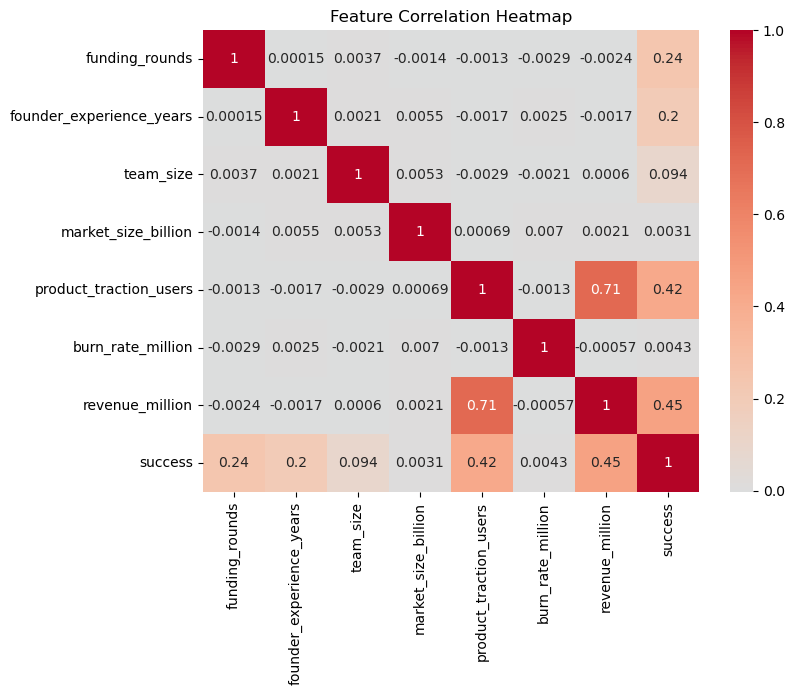

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_ml[numeric_cols + ['success']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

feature_cols = ['funding_rounds', 'founder_experience_years', 'team_size',
                'market_size_billion', 'product_traction_users', 
                'burn_rate_million', 'revenue_million']
# categoricals get one-hot encoded since correlation was weak but let's still include them properly
categorical_cols = ['investor_type', 'sector', 'founder_background']

df_model = pd.get_dummies(df_ml[feature_cols + categorical_cols + ['success']], 
                            columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=['success'])
y = df_model['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train success rate: {y_train.mean():.3f}, Test success rate: {y_test.mean():.3f}")

Train: (80000, 19), Test: (20000, 19)
Train success rate: 0.444, Test success rate: 0.444


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale numeric features - logistic regression is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test_scaled[feature_cols] = scaler.transform(X_test[feature_cols])

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.77      0.83      0.80     11122
           1       0.76      0.69      0.72      8878

    accuracy                           0.77     20000
   macro avg       0.77      0.76      0.76     20000
weighted avg       0.77      0.77      0.76     20000

ROC-AUC: 0.841

Confusion Matrix:
[[9234 1888]
 [2796 6082]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # no scaling needed

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.76      0.84      0.79     11122
           1       0.76      0.66      0.71      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.76      0.76     20000

ROC-AUC: 0.835

Confusion Matrix:
[[9306 1816]
 [3010 5868]]


In [10]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
6,revenue_million,1.028007
0,funding_rounds,0.722710
1,founder_experience_years,0.601304
4,product_traction_users,0.547897
2,team_size,0.287122
18,founder_background_serial_founder,0.037082
17,founder_background_first_time,0.032266
7,investor_type_none,0.023236
9,investor_type_tier2_vc,0.022037
8,investor_type_tier1_vc,0.018256


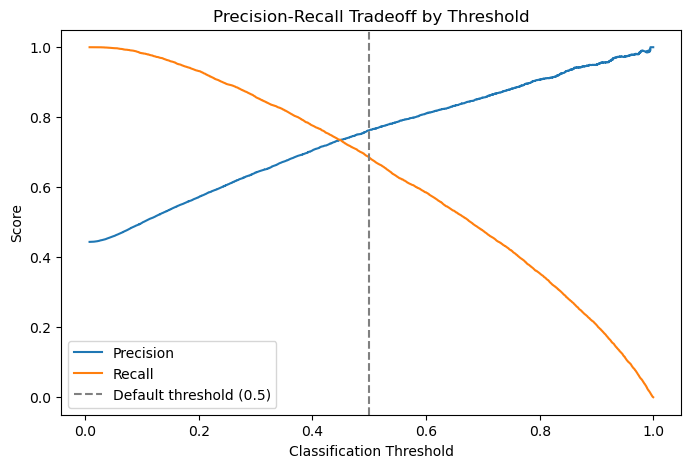

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff by Threshold')
plt.legend()
plt.show()

In [12]:
import numpy as np

# Check specific threshold values
for t in [0.5, 0.45, 0.40, 0.35, 0.30]:
    y_pred_t = (y_proba_lr >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} → Precision: {p:.3f}, Recall: {r:.3f}, F1: {f1:.3f}")

Threshold 0.50 → Precision: 0.763, Recall: 0.685, F1: 0.722
Threshold 0.45 → Precision: 0.736, Recall: 0.734, F1: 0.735
Threshold 0.40 → Precision: 0.705, Recall: 0.776, F1: 0.739
Threshold 0.35 → Precision: 0.673, Recall: 0.821, F1: 0.740
Threshold 0.30 → Precision: 0.642, Recall: 0.858, F1: 0.734


In [13]:
FINAL_THRESHOLD = 0.40

y_pred_final = (y_proba_lr >= FINAL_THRESHOLD).astype(int)

print("=== Final Model Performance (Threshold = 0.40) ===")
print(classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

=== Final Model Performance (Threshold = 0.40) ===
              precision    recall  f1-score   support

           0       0.81      0.74      0.77     11122
           1       0.71      0.78      0.74      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000


Confusion Matrix:
[[8239 2883]
 [1986 6892]]


In [16]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(log_reg, "models/investment_readiness_model.pkl")
joblib.dump(scaler, "models/feature_scaler.pkl")

# Save the exact feature column order - critical for reusing the model correctly later
feature_columns = list(X_train_scaled.columns)
joblib.dump(feature_columns, "models/feature_columns.pkl")

print("Model artifacts saved:")
print(os.listdir("models"))

Model artifacts saved:
['feature_columns.pkl', 'investment_readiness_model.pkl', 'feature_scaler.pkl']


In [17]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


Background dataset has 80000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=80000 when initializing the masker.


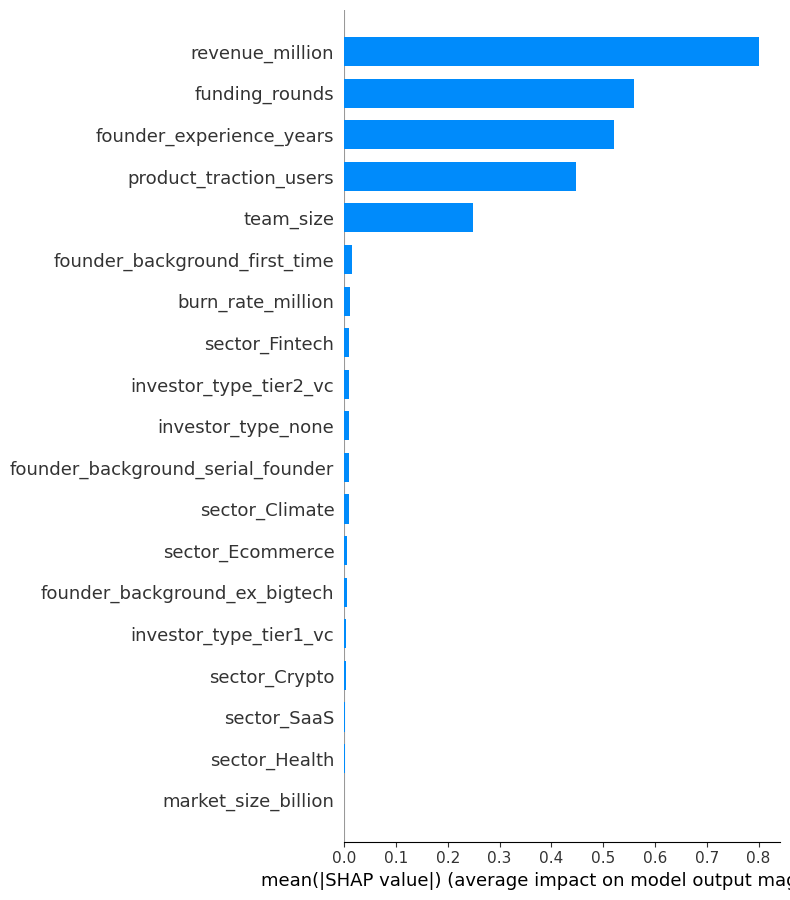

In [18]:
import shap

# LinearExplainer is the correct choice for logistic regression (fast, exact, not an approximation)
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Global feature importance - which features matter most across all predictions
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")

Predicted success probability: 0.045
Actual outcome: Failure


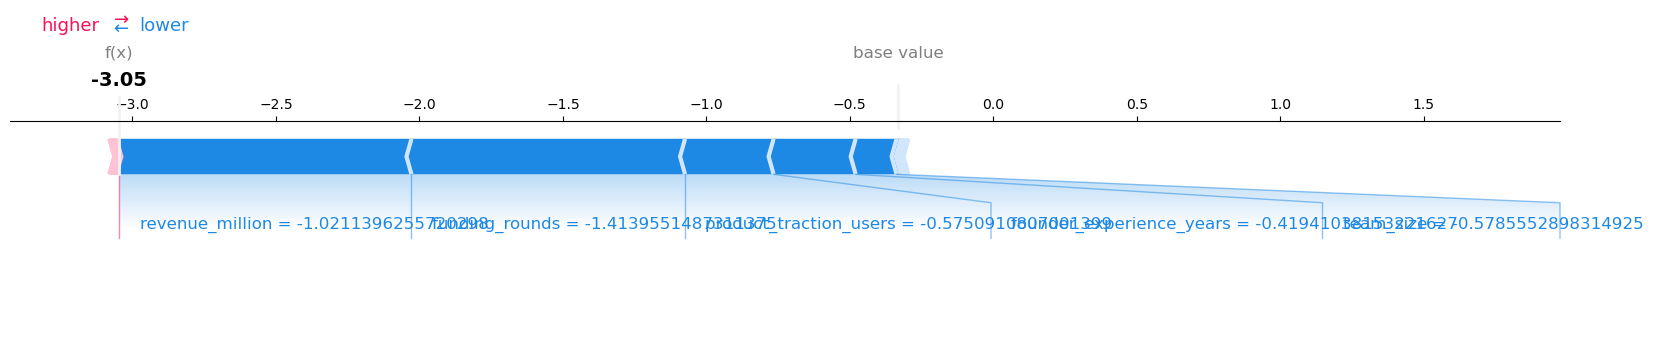

In [19]:
# Pick one example startup from the test set to explain in detail
idx = 0  # you can change this to explore different examples

sample = X_test_scaled.iloc[[idx]]
sample_pred_proba = log_reg.predict_proba(sample)[0][1]
sample_shap = explainer.shap_values(sample)

print(f"Predicted success probability: {sample_pred_proba:.3f}")
print(f"Actual outcome: {'Success' if y_test.iloc[idx] == 1 else 'Failure'}")

shap.force_plot(explainer.expected_value, sample_shap[0], sample, matplotlib=True)